---
# Market Risk Analysis: VaR, Expected Shortfall & Stress Testing
### A Multi-Asset Portfolio Risk Framework

This project implements a full market risk measurement framework 
for a mixed long/short portfolio of equity, investment grade credit, 
high yield credit, and US Treasury instruments. It covers instrument 
pricing via continuous compounding, first-order sensitivity analysis, 
historical simulation VaR and Expected Shortfall using a 2-year 
market data window (2021–2022), and stress testing under a severely 
adverse macro scenario using both full revaluation and Taylor 
approximation approaches.

**Key Findings:**
- Portfolio 1-day 99% VaR: $9,485 — worst scenario dated 2022-02-11, 
  coinciding with the highest U.S. CPI print since 1982
- Expected Shortfall at 97.5%: $9,974 — ES/VaR ratio of 1.05x 
  indicates a relatively thin tail beyond the VaR threshold
- Stress P&L under a 2008-style crisis scenario: -$410,371 — 
  43x larger than VaR, highlighting the gap between statistical 
  and scenario-based risk measures
- The IG corporate bond drives 65% of stress losses due to its 
  combination of high duration (10yr) and large position size
- The short US Treasury position provides a partial natural hedge, 
  generating +$38,722 in the stress scenario as rates rise

---


---
## Table of Contents
1. [Portfolio & Market Data](#preparations)
2. [Risk Factor Identification & Instrument Pricing](#question-1)
3. [Historical Simulation VaR & Expected Shortfall](#question-2)
4. [Stress Testing](#question-3)
5. [Risk Comparison & Limits Framework](#question-4)
6. [DV01 by Tenor Bucket](#dv01)
7. [VaR Backtesting](#backtesting)
8. [Risk Factor Correlation Analysis](#correlation)
9. [FRTB Liquidity Horizon Scaling](#frtb)

---


<a id='preparations'></a>

## Portfolio & Market Data


In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [71]:
# --- Visualization style ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.edgecolor':   '#cccccc',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})
PALETTE = ['#2C5F8A', '#E07B39', '#4A9B6F', '#C94040', '#7B5EA7', '#5A9BAA']



In [72]:
### load dataset
df = pd.read_excel("data/market data time series.xlsx")
df.head()

,Date,SPY ETF ($),Risk-free Yield @ 10y (%),Risk-free Yield @ 5y (%),Risk-free Yield @ 2y (%),Credit Spread IG (bps),Credit Spread HY (bps)
0,2022-12-29,383.44,3.817,3.942,4.365,108.0,514.331655
1,2022-12-28,376.66,3.885,3.968,4.354,110.0,511.023644
2,2022-12-27,381.40,3.844,3.941,4.377,110.0,491.509226
3,2022-12-23,382.91,3.749,3.858,4.323,109.0,492.298793
4,2022-12-22,380.72,3.681,3.804,4.272,111.0,494.710577


In [73]:
#setting the base variables
COUPONS = {"IG": 5e-2,
          "HY": 7e-2,
          "UST": 3.875e-2}  # decimal fraction
UST_YIELD = {"10y": 3.56e-2,
             "5y": 3.7e-2,
             "2y": 4.25e-2}  # decimal fraction
CREDIT_SPREAD = {"IG": 112e-4,
                 "HY": 295e-4,
                 "UST": 0}  # decimal fraction
NUM_POSITIONS = {"SPY": 30,
                 "IG": 1e4,
                 "HY": 1e4,
                 "UST": -2e4}
SPY_PRESENT_PRICE = 380.82  # price per unit SPY, USD
COUPON_PAY_FREQ = 2  # twice per year, i.e., semi-annual, for all instrument in portfolio
BOND_NOTIONAL = 100  # notional in USD

In [ ]:
### for stress testing
CS_SHOCK = {"AAA": 238.9e-4,
            "AA": 266.7e-4,
            "A": 337.6e-4,
            "BBB": 443e-4,
            "BB": 1012e-4,
            "B": 1372.1e-4}  # decimal fraction
UST_SHOCK = {"10y": 49.4e-4,
             "5y": 42.3e-4,
             "2y": 29.9e-4}  # decimal fraction
SPY_SHOCK = -38.3e-2  # decimal fraction

<a id='question-1'></a>

## Risk Factor Identification & Instrument Pricing


**SPY ETF:** driven by equity price risk. P&L moves directly with SPY spot price.

**IG Corporate Bond (10yr):** exposed to interest rate risk (10yr UST yield) and 
IG credit spread risk. Long duration makes it highly sensitive to rate moves.

**HY Corporate Bond (2yr):** exposed to interest rate risk (2yr UST yield) and 
HY credit spread risk. Short duration but dominated by credit spread volatility.

**US Treasury (5yr, short):** exposed to interest rate risk (5yr UST yield) only, 
no credit spread. Short position means rate increases generate gains.


### Present value calculation per position for each instrument using continuous compounding discounting.

Each bond's present value is computed by discounting all future cash flows 
using continuous compounding:

$$PV = \sum_{i=1}^{n} C \cdot e^{-r \cdot t_i} + F \cdot e^{-r \cdot t_n}$$

Where:
- $C$ = coupon payment per period = $\frac{\text{coupon rate} \times \text{notional}}{\text{frequency}}$
- $F$ = face value (notional = \$100)
- $r$ = discount rate = risk-free yield + credit spread (in decimal)
- $t_i$ = time to $i$-th cash flow in years (semi-annual: 0.5, 1.0, 1.5, ...)
- $n$ = total number of periods = maturity (years) × frequency

The eps parameter adds a shock to the discount rate, enabling sensitivity 
calculations (PV01, CS01) via numerical differentiation.


In [75]:
def compute_bond_price(instrument, year, eps=0):
    """
    This function computes the present value per position for a given bond, with a given time to mature.
    :param instrument: bond name
    :param year: time to mature
    :param eps: shock, default is 0. This will be used for sensitivity analysis later.
    :return present value per position
    """

    # Retrieve coupon rate and build discount rate
    # Discount rate = risk-free yield + credit spread (both in decimal)
    # eps shifts the discount rate for sensitivity calculations
    
    coupon_rate = COUPONS[instrument]  # already in decimal (e.g. 0.05)
    
    if instrument == 'IG':
        r = UST_YIELD['10y'] + CREDIT_SPREAD['IG'] + eps
    elif instrument == 'HY':
        r = UST_YIELD['2y'] + CREDIT_SPREAD['HY'] + eps
    elif instrument == 'UST':
        r = UST_YIELD['5y'] + CREDIT_SPREAD['UST'] + eps
    
    # Semi-annual payments: t = 0.5, 1.0, 1.5, ..., maturity
    coupon_payment = (coupon_rate * BOND_NOTIONAL) / COUPON_PAY_FREQ
    num_periods = int(year * COUPON_PAY_FREQ)  # total number of coupon payments
    times = np.array([i / COUPON_PAY_FREQ for i in range(1, num_periods + 1)])
    
    # Discount each cash flow
    # Coupon PV: sum of C * e^(-r * t) for each period
    # Principal PV: F * e^(-r * T) at maturity only
    pv_coupons = np.sum(coupon_payment * np.exp(-r * times))
    pv_principal = BOND_NOTIONAL * np.exp(-r * year)
    
    unit_present_price = pv_coupons + pv_principal
    
    return unit_present_price


In [76]:
present_price_per_position_SPY = SPY_PRESENT_PRICE #no need for discounting
#present value per position for each instrument using continuous compounding
present_price_per_position_IG = compute_bond_price('IG',  year=10)
present_price_per_position_HY = compute_bond_price('HY',  year=2)
present_price_per_position_UST = compute_bond_price('UST',  year=5)

In [77]:
print("Present value per position:")
print("SPY ETF: ${}".format("%.2f" % present_price_per_position_SPY))
print("IG Corporate bond (10 years): ${}".format("%.2f" % present_price_per_position_IG))
print("HY Corporate bond (2 years): ${}".format("%.2f" % present_price_per_position_HY))
print("US Treasury (5 years): ${}".format("%.2f" % present_price_per_position_UST))

Present value per position:
SPY ETF: $380.82
IG Corporate bond (10 years): $102.09
HY Corporate bond (2 years): $99.39
US Treasury (5 years): $100.64


In [78]:
# Export results
present_price_per_position = {
    "SPY": present_price_per_position_SPY,
    "IG": present_price_per_position_IG,
    "HY": present_price_per_position_HY,
    "UST": present_price_per_position_UST
}
present_price_per_position_df = pd.DataFrame.from_dict(present_price_per_position, orient='index', columns=['Present Price'])
os.makedirs('output', exist_ok=True)
present_price_per_position_df.to_csv('output/Q1_2_present_price_per_position.csv')

### 1.3 Calculate the first-order sensitivity against each risk factor for the portfolio (note, for equity delta use 1% price sensitivity, for PV01 and CS01 use +1bps sensitivities)

$$\text{Sensitivity} = PV(\text{shocked}) - PV(\text{base})$$

Three sensitivities are required:

**Equity Delta** — P&L change for a +1% move in SPY price:
$$\Delta_{equity} = \text{positions}_{SPY} \times S_{SPY} \times 1\%$$

**PV01** — P&L change for a +1 bps parallel shift in risk-free yields:
$$PV01 = \sum_{\text{bonds}} \left[ PV(r + 0.0001) - PV(r) \right] \times \text{positions}$$

**CS01** — P&L change for a +1 bps widening in credit spreads:
$$CS01 = \sum_{\text{credit bonds}} \left[ PV(cs + 0.0001) - PV(cs) \right] \times \text{positions}$$

Note: UST has no credit spread, so it does not contribute to CS01.
Both PV01 and CS01 are expected to be negative (rising rates/spreads
reduce bond prices.) The short UST position partially offsets PV01.


In [79]:
def func_shock(instrument, years, eps=0):
  """
  This function computes the total shock for all positions for a given bond, with a given time to mature.
  :param instrument: bond name
  :param years: time to mature
  :param eps: shock 
  :return total shock for all positions
  """
  # Price change per position under the shock
  price_change = compute_bond_price(instrument, years, eps=eps) - \
                 compute_bond_price(instrument, years, eps=0)
    
  # Multiply by number of positions
  total_shock = price_change * NUM_POSITIONS[instrument]
    
  return total_shock

In [80]:
# Equity Delta
# Delta = positions × current price × 1%
equity_delta = NUM_POSITIONS['SPY'] * SPY_PRESENT_PRICE * 0.01

# PV01: P&L impact of +1 bps parallel shift in risk-free yields 
# 1 bps = 0.0001 in decimal; applied to ALL bonds (rates affect everyone)
eps_1bps = 1e-4
PV01 = (func_shock('IG',  years=10, eps=eps_1bps) +
        func_shock('HY',  years=2,  eps=eps_1bps) +
        func_shock('UST', years=5,  eps=eps_1bps))

# CS01: P&L impact of +1 bps widening in credit spreads 
# Only affects credit instruments (IG and HY), not the UST
CS01 = (func_shock('IG', years=10, eps=eps_1bps) +
        func_shock('HY', years=2,  eps=eps_1bps))

In [81]:
print("First-order sensitivity:")
print("Equity Delta: ${}".format("%.2f" % equity_delta))
print("PV01: ${}".format("%.2f" % PV01))
print("CS01: ${}".format("%.2f" % CS01))

First-order sensitivity:
Equity Delta: $114.25
PV01: $-82.05
CS01: $-1006.65


In [82]:
# Export results
sensitivity = {
    "Equity Delta": equity_delta,
    "PV01": PV01,
    "CS01": CS01
}
sensitivity_df = pd.DataFrame.from_dict(sensitivity, orient='index', columns=['Sensitivity'])
sensitivity_df.to_csv('output/Q1_3_sensitivity.csv')

<a id='question-2'></a>

## Historical Simulation VaR & Expected Shortfall


### 2.1 Generate historical shocks for each risk factor and plot the distribution histogram
assuming the following
+	Historical simulation approach with 2-year window from 2021-1-4 to 2022-12-29. 
+	Equity spot shock is relative, risk-free yield and credit spread shocks are absolute.


Shock conventions:
- **SPY:** *relative* shock — percentage return day-over-day:
$$\delta_{SPY,t} = \frac{S_t - S_{t-1}}{S_{t-1}}$$

- **Rates & Spreads:** *absolute* shock — arithmetic difference:
$$\delta_{r,t} = r_t - r_{t-1}$$

**Unit note:** Yields in the dataset are in % (e.g. 3.817), so the 
absolute difference is already in percentage points. We multiply by 100 
to convert to bps. Credit spreads are already in bps, so we take the 
difference directly.

With 502 data points, we get 501 daily shock scenarios.


In [83]:
# Sorting by date ascending so that the differences go forward in time
df_sorted = df.sort_values('Date').reset_index(drop=True)

daily_shock_SPY =  df_sorted['SPY ETF ($)'].pct_change().dropna().values# relative shock (percent)
daily_shock_UST_IG_10 = df_sorted['Risk-free Yield @ 10y (%)'].diff().dropna().values * 100 # absolute shock (bps)
daily_shock_UST_5 =  df_sorted['Risk-free Yield @ 5y (%)'].diff().dropna().values  * 100 # absolute shock (bps)
daily_shock_UST_HY_2 = df_sorted['Risk-free Yield @ 2y (%)'].diff().dropna().values  * 100  # absolute shock (bps)
daily_shock_CS_IG =   df_sorted['Credit Spread IG (bps)'].diff().dropna().values # absolute shock (bps)
daily_shock_CS_HY =   df_sorted['Credit Spread HY (bps)'].diff().dropna().values # absolute shock (bps)


print(f"Number of shock scenarios: {len(daily_shock_SPY)}")
print(f"\nSPY shock range:    {daily_shock_SPY.min()*100:.2f}% to {daily_shock_SPY.max()*100:.2f}%")
print(f"UST 10y shock range: {daily_shock_UST_IG_10.min():.2f} to {daily_shock_UST_IG_10.max():.2f} bps")
print(f"CS IG shock range:   {daily_shock_CS_IG.min():.2f} to {daily_shock_CS_IG.max():.2f} bps")
print(f"CS HY shock range:   {daily_shock_CS_HY.min():.2f} to {daily_shock_CS_HY.max():.2f} bps")

Number of shock scenarios: 501

SPY shock range:    -4.35% to 5.50%
UST 10y shock range: -28.10 to 23.70 bps
CS IG shock range:   -9.00 to 7.00 bps
CS HY shock range:   -37.92 to 40.47 bps


In [84]:
# Export results
daily_shock = {
    "SPY": daily_shock_SPY,
    "UST_10": daily_shock_UST_IG_10,
    "UST_5": daily_shock_UST_5,
    "UST_2": daily_shock_UST_HY_2,
    "CS_IG": daily_shock_CS_IG,
    "CS_HY": daily_shock_CS_HY
}
daily_shock_df = pd.DataFrame.from_dict(daily_shock)
daily_shock_df.to_csv('output/Q2_1_daily_shock.csv', index=False)

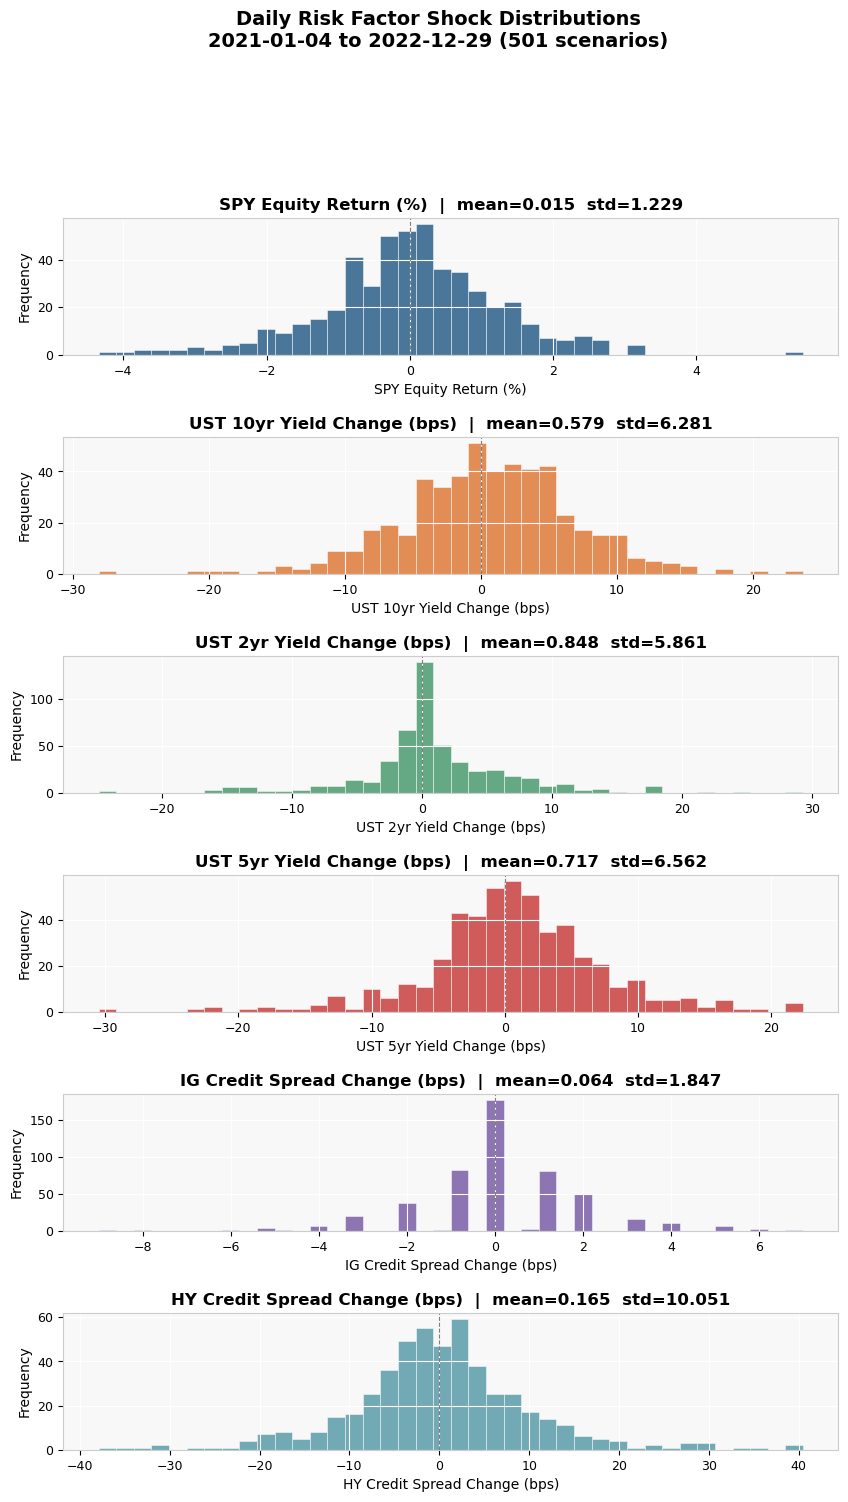

In [85]:
fig, axes = plt.subplots(6, 1, figsize=(10, 16))
fig.suptitle('Daily Risk Factor Shock Distributions\n2021-01-04 to 2022-12-29 (501 scenarios)',
             fontsize=14, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.6)

shock_data = [
    (daily_shock_SPY * 100, 'SPY Equity Return (%)', PALETTE[0]),
    (daily_shock_UST_IG_10, 'UST 10yr Yield Change (bps)', PALETTE[1]),
    (daily_shock_UST_HY_2,  'UST 2yr Yield Change (bps)',  PALETTE[2]),
    (daily_shock_UST_5,     'UST 5yr Yield Change (bps)',  PALETTE[3]),
    (daily_shock_CS_IG,     'IG Credit Spread Change (bps)', PALETTE[4]),
    (daily_shock_CS_HY,     'HY Credit Spread Change (bps)', PALETTE[5]),
]

for ax, (data, label, color) in zip(axes, shock_data):
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    mean_val = data.mean()
    std_val  = data.std()
    ax.set_title(f'{label}  |  mean={mean_val:.3f}  std={std_val:.3f}')

plt.savefig('output/daily_shock_histogram.png', bbox_inches='tight', dpi=150)
plt.show()



### 2.2	Calculate the 1-day Value-at-Risk at 99 percentile confidence level (6th worst) and specify the scenario date together with the scenario risk factor moves. Please use Taylor approach with first-order sensitivities (see chapter 15.11 for definition).


For each of the 501 historical scenarios, we approximate the portfolio P&L 
using the **Taylor (first-order) approach**:

$$\Delta PV \approx \Delta_{equity} \cdot \delta_{SPY} 
+ PV01 \cdot \delta_{r} 
+ CS01 \cdot \delta_{cs}$$

Where each $\delta$ is the historical daily shock for that scenario.

**VaR definition:** With 501 scenarios, the 99% VaR is the **6th worst** 
loss (1% of 501 ≈ 5.01, so the 6th worst scenario is the VaR threshold).

VaR is reported as a negative number representing the loss magnitude.


In [86]:
# Date index aligned with shock scenarios 
dates = df_sorted['Date'].iloc[1:].reset_index(drop=True)
# --- Compute per-1bps sensitivities separately ---
# Rate sensitivity (PV01 component per instrument)
pv01_IG  = func_shock('IG',  years=10, eps=eps_1bps)  # $ per 1bps rate move
pv01_HY  = func_shock('HY',  years=2,  eps=eps_1bps)  # $ per 1bps rate move
pv01_UST = func_shock('UST', years=5,  eps=eps_1bps)  # $ per 1bps rate move

# Credit spread sensitivity (CS01 component per instrument)
cs01_IG  = func_shock('IG',  years=10, eps=eps_1bps)  # $ per 1bps spread move
cs01_HY  = func_shock('HY',  years=2,  eps=eps_1bps)  # $ per 1bps spread move
# UST has no credit spread — cs01_UST = 0

# --- SPY P&L ---
# equity_delta is $ sensitivity to 1% move, scale by actual shock
pnl_SPY = equity_delta * (daily_shock_SPY / 0.01)

# --- IG Bond P&L: rate component + credit spread component ---
pnl_IG = (pv01_IG * daily_shock_UST_IG_10 +
          cs01_IG * daily_shock_CS_IG)

# --- HY Bond P&L: rate component + credit spread component ---
pnl_HY = (pv01_HY * daily_shock_UST_HY_2 +
          cs01_HY * daily_shock_CS_HY)

# --- UST P&L: rate only, no credit spread ---
pnl_UST = pv01_UST * daily_shock_UST_5

# --- Portfolio P&L ---
pnl_portfolio = pnl_SPY + pnl_IG + pnl_HY + pnl_UST



In [87]:
### Compute 99th percentile for P&L for each instrument
var99_SPY       = pnl_SPY[np.argsort(pnl_SPY)[5]]
var99_IG        = pnl_IG[np.argsort(pnl_IG)[5]]
var99_HY        = pnl_HY[np.argsort(pnl_HY)[5]]
var99_UST       = pnl_UST[np.argsort(pnl_UST)[5]]
var99_portfolio = pnl_portfolio[np.argsort(pnl_portfolio)[5]]

date_SPY       = dates.iloc[np.argsort(pnl_SPY)[5]].strftime('%Y-%m-%d')
date_IG        = dates.iloc[np.argsort(pnl_IG)[5]].strftime('%Y-%m-%d')
date_HY        = dates.iloc[np.argsort(pnl_HY)[5]].strftime('%Y-%m-%d')
date_UST       = dates.iloc[np.argsort(pnl_UST)[5]].strftime('%Y-%m-%d')
date_portfolio = dates.iloc[np.argsort(pnl_portfolio)[5]].strftime('%Y-%m-%d')

var99 = {
    "SPY":       [var99_SPY, date_SPY],
    "IG":        [var99_IG, date_IG],
    "HY":        [var99_HY, date_HY],
    "UST":       [var99_UST, date_UST],
    "Portfolio": [var99_portfolio, date_portfolio]
}

var99_df = round(pd.DataFrame.from_dict(var99, orient='index', columns=['99th Percentile', 'Date']), 2)
display(var99_df)

,99th Percentile,Date
SPY,-386.71,2022-08-26
IG,-13084.34,2022-03-14
HY,-5602.23,2022-09-13
UST,-16920.11,2021-11-26
Portfolio,-9484.75,2022-02-11


### A few comments on the result:

**Portfolio worst day: 2022-02-11**: 
On February 11, 2022, markets reacted sharply to a hotter-than-expected 
U.S. CPI print (7.5% YoY which is the highest since 1982), triggering a broad 
risk-off selloff. SPY fell sharply, IG and HY credit spreads widened, 
and yields spiked. All four risk factors moved against the portfolio 
simultaneously, making this the worst single day in the 2-year window.

**UST worst day: 2021-11-26**: 
The 5yr Treasury yield dropped sharply on news of the Omicron COVID variant, 
as markets fled to safe-haven assets. Since the portfolio is short UST, 
a falling yield (rising bond price) generates a loss on this position.

**IG worst day: 2022-03-14**: 
Early March 2022 saw aggressive Fed rate hike pricing following Russia's 
invasion of Ukraine and persistent inflation. The 10yr yield spiked 
significantly, crushing the long 10yr IG bond position which has the 
highest duration in the portfolio.


In [88]:
# Export results
os.makedirs('output', exist_ok=True)
var99_df.to_csv('output/Q2_2_var99.csv')

### 2.3 Calculate the 1-day Expected Shortfall at 97.5 percentile confidence level (top 13 worst scenarios). Please use Taylor approach.


**Expected Shortfall (ES)** basically answers: 
"Given that we exceed VaR, what is the expected loss?"

$$ES_{97.5\%} = \frac{1}{k} \sum_{i=1}^{k} L_i$$

Where $L_i$ are the $k$ worst P&L scenarios beyond the 97.5% threshold.

With 501 scenarios: $k = \lfloor 501 \times 2.5\% \rfloor = 13$ worst scenarios.

ES is the preferred risk measure under Basel III/IV (FRTB) over VaR because:
- It satisfies subadditivity (portfolio ES ≤ sum of individual ES)
- It captures tail risk
- It penalizes fat-tailed distributions more appropriately


In [89]:
### Compute Expected Shortfall at 97.5 percentile using np.sort or np.percentile

sorted_pnl = np.sort(pnl_portfolio)  # ascending, worst first

ES_975 = np.mean(sorted_pnl[:13])

print("Expected Shortfall at 97.5th percentile: ${:,.0f}".format(ES_975))
print("(Average of the 13 worst daily P&L scenarios)")
print(f"\nFor reference, 99th percentile VaR was: ${var99_portfolio:,.0f}")
print(f"ES/VaR ratio: {ES_975/var99_portfolio:.2f}x")

Expected Shortfall at 97.5th percentile: $-9,974
(Average of the 13 worst daily P&L scenarios)

For reference, 99th percentile VaR was: $-9,485
ES/VaR ratio: 1.05x


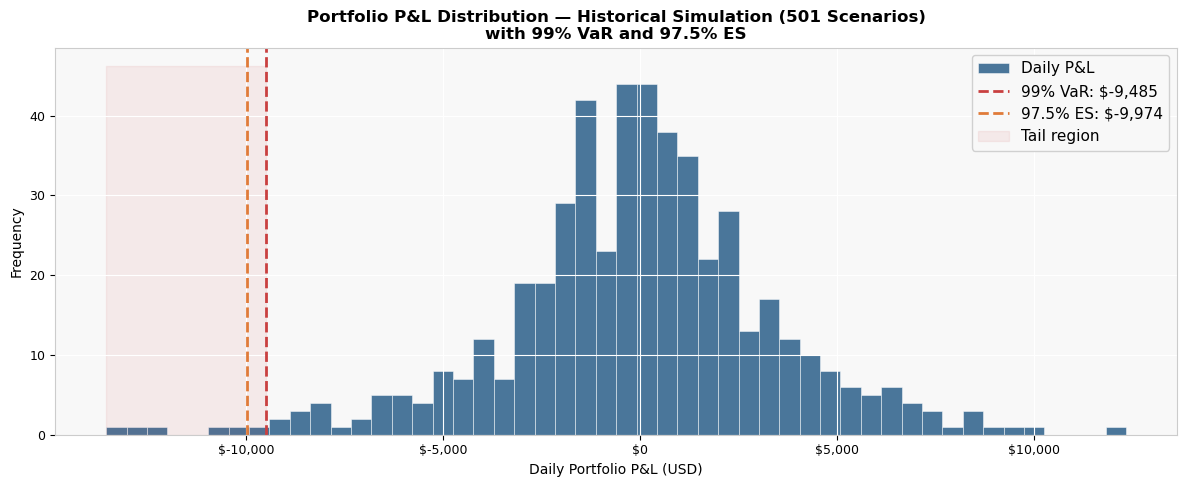

In [90]:
# P&L Distribution with VaR and ES marked
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(pnl_portfolio, bins=50, color=PALETTE[0], edgecolor='white',
        linewidth=0.4, alpha=0.85, label='Daily P&L')
ax.axvline(var99_portfolio, color=PALETTE[3], linewidth=2,
           linestyle='--', label=f'99% VaR: ${var99_portfolio:,.0f}')
ax.axvline(ES_975, color=PALETTE[1], linewidth=2,
           linestyle='--', label=f'97.5% ES: ${ES_975:,.0f}')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 100],
                  pnl_portfolio.min(), var99_portfolio,
                  color=PALETTE[3], alpha=0.08, label='Tail region')
ax.set_xlabel('Daily Portfolio P&L (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Portfolio P&L Distribution — Historical Simulation (501 Scenarios)\nwith 99% VaR and 97.5% ES')
ax.legend(framealpha=0.9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('output/pnl_distribution.png', bbox_inches='tight', dpi=150)
plt.show()



In [91]:
# Export results
expected_shortfall = {
    "Portfolio": ES_975
}
expected_shortfall_df = pd.DataFrame.from_dict(expected_shortfall, orient='index', columns=['Expected Shortfall'])
expected_shortfall_df.to_csv('output/Q2_3_expected_shortfall.csv')

<a id='question-3'></a>

## Stress Testing


### 3.1 Given a severely adverse stress scenarios as follows, calculate the P&L loss for each instrument (including position size) and the total portfolio. Please use full revaluation approach.

+ US equity spot price relative shock is -38.3%
+ US risk-free yields are increased by +29.9bps @2yr, 42.30bps @5yr, and 49.40bps @10yr.
+ US credit spread widens by +337.60bps for IG A rating and +1,012bps for HY BB rating.


In full revaluation, we reprice every instrument from scratch after 
applying the stress shocks, then compute P&L as:

$$\text{P\&L} = \left[ PV(\text{shocked}) - PV(\text{base}) \right] \times \text{positions}$$

The severe adverse scenario applies simultaneous shocks across all risk factors:

| Risk Factor | Shock |
|---|---|
| SPY equity price | -38.3% |
| UST yield @ 2yr | +29.9 bps |
| UST yield @ 5yr | +42.3 bps |
| UST yield @ 10yr | +49.4 bps |
| Credit spread IG (A) | +337.6 bps |
| Credit spread HY (BB) | +1,012 bps |

This scenario approximates a **2008-style financial crisis**: simultaneous 
equity crash, credit crisis, and rate spike. Full revaluation captures 
**convexity effects** that Taylor approximation misses.


In [92]:
# SPY: full revaluation
SPY_shocked_price = SPY_PRESENT_PRICE * (1 + SPY_SHOCK)
SPY_shock_full_reval = (SPY_shocked_price - SPY_PRESENT_PRICE) * NUM_POSITIONS['SPY']

# Bonds: func_shock with combined rate + credit spread shock
IG_shock_full_reval  = func_shock('IG',  years=10, eps=UST_SHOCK['10y'] + CS_SHOCK['A'])
HY_shock_full_reval  = func_shock('HY',  years=2,  eps=UST_SHOCK['2y']  + CS_SHOCK['BB'])
UST_shock_full_reval = func_shock('UST', years=5,  eps=UST_SHOCK['5y'])

# Portfolio total
portfolio_shock_full_reval = (SPY_shock_full_reval + IG_shock_full_reval + 
                               HY_shock_full_reval + UST_shock_full_reval)

In [93]:
full_reval = {
    "SPY": SPY_shock_full_reval,
    "IG": IG_shock_full_reval,
    "HY": HY_shock_full_reval,
    "UST": UST_shock_full_reval,
    "Portfolio": portfolio_shock_full_reval
}
full_reval_df = round(pd.DataFrame.from_dict(full_reval, orient='index', columns=['Stress Testing P&L (Full Reval)'])
    , 2)

display(full_reval_df)

,Stress Testing P&L (Full Reval)
SPY,-4375.62
IG,-266659.59
HY,-178057.34
UST,38722.01
Portfolio,-410370.54


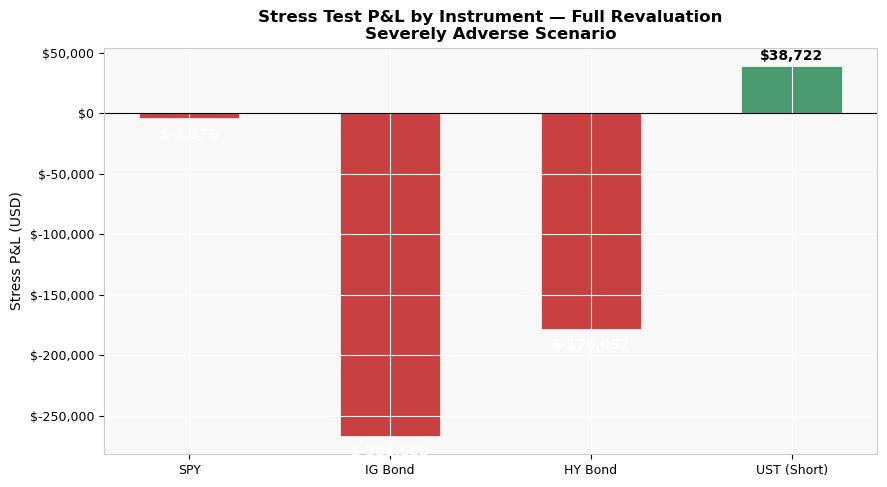

In [94]:
# Risk contribution bar chart
fig, ax = plt.subplots(figsize=(9, 5))
instruments  = ['SPY', 'IG Bond', 'HY Bond', 'UST (Short)']
contributions = [SPY_shock_full_reval, IG_shock_full_reval,
                 HY_shock_full_reval,  UST_shock_full_reval]
bar_colors = [PALETTE[3] if v < 0 else PALETTE[2] for v in contributions]
bars = ax.bar(instruments, contributions, color=bar_colors,
              edgecolor='white', linewidth=0.5, width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, contributions):
    ypos = val - 8000 if val < 0 else val + 3000
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'${val:,.0f}', ha='center', va='top' if val < 0 else 'bottom',
            fontsize=10, fontweight='bold', color='white' if val < 0 else 'black')
ax.set_ylabel('Stress P&L (USD)')
ax.set_title('Stress Test P&L by Instrument — Full Revaluation\nSeverely Adverse Scenario')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('output/stress_contribution.png', bbox_inches='tight', dpi=150)
plt.show()



### Note: 

The portfolio loses $410,371 under the severely adverse scenario. The IG 
bond drives 65% of total losses (-$266,660) due to its combination of high 
duration (10yr) and large position size, the 387 bps combined rate and spread 
shock hits it hardest. The HY bond contributes -$178,057 despite its short 
tenor, as the 1,012 bps spread widening overwhelms the duration benefit. The 
short UST position provides a partial natural hedge (+$38,722) as rates rise, 
but offsets only ~9% of total losses. 
### Issue: The portfolio has no credit hedge.


In [95]:
# Export results
full_reval_df.to_csv('output/Q3_1_stress_testing_full_reval.csv')

### 3.2 Repeat the calculation in 3.1 using Taylor based approach.


Using first-order sensitivities scaled by the stress shock magnitudes:

$$\Delta PV \approx \Delta_{equity} \cdot \delta_{SPY} + PV01 \cdot \delta_{r} + CS01 \cdot \delta_{cs}$$


In [96]:
### compute profit and loss (P&L), Taylor approach

# SPY: Taylor (same as full reval for equity — linear by nature)
SPY_shock_taylor = equity_delta * (SPY_SHOCK / 0.01)

# Bonds: sensitivity × shock in bps
# Rate shock component (PV01 × rate shock)
IG_shock_taylor  = (func_shock('IG',  years=10, eps=eps_1bps) * UST_SHOCK['10y']  * 1e4 +
                    func_shock('IG',  years=10, eps=eps_1bps) * CS_SHOCK['A']     * 1e4)

HY_shock_taylor  = (func_shock('HY',  years=2,  eps=eps_1bps) * UST_SHOCK['2y']   * 1e4 +
                    func_shock('HY',  years=2,  eps=eps_1bps) * CS_SHOCK['BB']    * 1e4)

UST_shock_taylor = func_shock('UST', years=5,  eps=eps_1bps) * UST_SHOCK['5y']   * 1e4

# Portfolio total
portfolio_shock_taylor = (SPY_shock_taylor + IG_shock_taylor + 
                          HY_shock_taylor  + UST_shock_taylor)

In [97]:
taylor = {
    "SPY": SPY_shock_taylor,
    "IG": IG_shock_taylor,
    "HY": HY_shock_taylor,
    "UST": UST_shock_taylor,
    "Portfolio": portfolio_shock_taylor
}
taylor_df = round(pd.DataFrame.from_dict(taylor, orient='index', columns=['Stress Testing P&L (Taylor)']), 2)
display(taylor_df)


,Stress Testing P&L (Taylor)
SPY,-4375.62
IG,-316477.39
HY,-196791.79
UST,39110.42
Portfolio,-478534.37


In [98]:
# Export results
taylor_df.to_csv('output/Q3_2_stress_testing_taylor.csv')

### 3.3 Compare the results of full revaluation and Taylor's approach in stress testing P&L calculation. Which one is better? 
Please limit your answer within 100 words.


Taylor overstates the portfolio loss (-$478,534 vs. -$410,371 full reval, 
a 16.6% difference). This occurs because Taylor uses a linear approximation 
of the price-yield relationship, ignoring convexity. Bonds exhibit positive 
convexity, meaning price declines slow as yields rise. Taylor misses this 
cushioning effect, overstating losses for large shocks. Full revaluation 
reprices each instrument using the actual pricing model, capturing convexity 
correctly. For stress testing with large shocks, full revaluation is always 
preferred. Taylor is usually better for small, incremental moves in 
day-to-day risk monitoring.


<a id='question-4'></a>

## Risk Comparison & Limits Framework


### 4.1 Compare the risk measures from IRM (i.e., VaR and ES) and ST (i.e., P&L loss), and discuss your observations.

Please limit your answer within 100 words.


| Measure | Value |
|---|---|
| 99% VaR (1-day) | -$9,485 |
| ES 97.5% (1-day) | -$9,974 |
| Stress Test P&L (Full Reval) | -$410,371 |

The stress loss is **43x larger** than VaR. This gap exists because VaR/ES 
are **statistically-driven** and bounded by what historically occurred in the 
2021-2022 window while stress testing applies **hypothetical extreme shocks** that 
may never appear in historical data. VaR also assumes normal market 
functioning, while stress scenarios model simultaneous multi-factor crises. 
The two measures are **complementary**: VaR captures day-to-day tail risk; 
stress testing captures existential, crisis-level losses.


### 4.2 If you are a risk manager for this portfolio, how you will setup risk limits and why?

Please limit your answer within 200 words.


If I were managing this portfolio, I would build limits around three layers:

- The first is a **VaR limit of 15,000 USD** (1-day, 99%). Our current VaR sits at 9,485 USD, so this gives reasonable breathing room for normal market moves while still flagging anything unusual. A breach would trigger a mandatory position review before any new trades.

- The second is a **stress loss limit of 500,000 USD**. Our full revaluation stress P&L came in at 410,371 USD, so this cap ensures we stay within a manageable range under a crisis scenario while still aligning with Basel III's expectation that banks hold capital against extreme events.

- The third layer is **sensitivity limits**. Looking at our Greeks, credit spread risk is clearly the dominant exposure with a CS01 of 1,007 USD per bps, far exceeding our PV01 of 82 USD. I would set the tightest limit here, around 1,500 USD CS01, because the IG bond alone drives roughly 65% of our stress loss and there is no credit hedge in this portfolio. PV01 and equity delta have much more headroom given current levels.


<a id='dv01'></a>

## DV01 by Tenor Bucket


Rate sensitivity broken down by yield curve point. DV01 (Dollar Value of 1 basis point) measures the P&L impact of a +1bps move at each tenor independently, isolating where on the yield curve the portfolio is most exposed.


,Tenor,Instrument,DV01 ($/bps)
0,2yr,HY Corporate Bond,-188.88
1,5yr,US Treasury (Short),924.60
2,10yr,IG Corporate Bond,-817.77


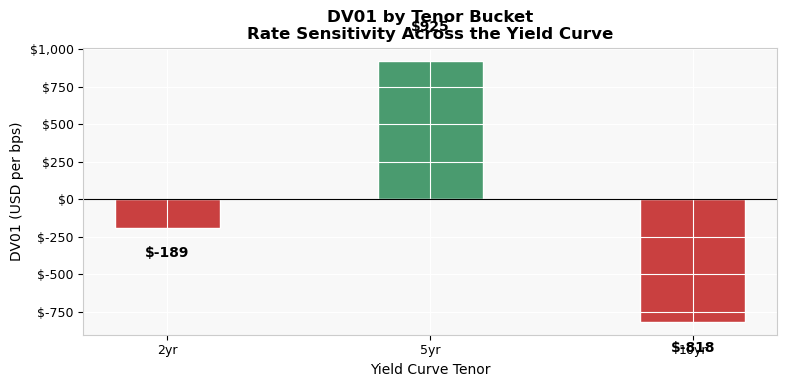

In [99]:
# DV01 at each tenor: P&L impact of +1bps move at that curve point only
# Each instrument is sensitive to one specific tenor

dv01_2y  = pv01_HY   # HY bond discounted at 2yr rate
dv01_5y  = pv01_UST  # UST discounted at 5yr rate  
dv01_10y = pv01_IG   # IG bond discounted at 10yr rate

dv01_df = pd.DataFrame({
    'Tenor':       ['2yr', '5yr', '10yr'],
    'Instrument':  ['HY Corporate Bond', 'US Treasury (Short)', 'IG Corporate Bond'],
    'DV01 ($/bps)': [round(dv01_2y, 2), round(dv01_5y, 2), round(dv01_10y, 2)],
    'Abs DV01':    [abs(round(dv01_2y, 2)), abs(round(dv01_5y, 2)), abs(round(dv01_10y, 2))]
})
display(dv01_df[['Tenor', 'Instrument', 'DV01 ($/bps)']])

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = [PALETTE[2] if v >= 0 else PALETTE[3] for v in 
          [dv01_2y, dv01_5y, dv01_10y]]
ax.bar(dv01_df['Tenor'], dv01_df['DV01 ($/bps)'], 
       color=colors, width=0.4, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Yield Curve Tenor')
ax.set_ylabel('DV01 (USD per bps)')
ax.set_title('DV01 by Tenor Bucket\nRate Sensitivity Across the Yield Curve')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (tenor, val) in enumerate(zip(dv01_df['Tenor'], 
                                      dv01_df['DV01 ($/bps)'])):
    ax.text(i, val + (200 if val >= 0 else -200), f'${val:,.0f}',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('output/dv01_by_tenor.png', bbox_inches='tight', dpi=150)
plt.show()



The portfolio's largest rate exposure is at the **10yr tenor** via 
the long IG bond (DV01: **-$818/bps**), reflecting its combination 
of long duration and large position size. The short UST position 
at the 5yr point provides a partial offset (positive DV01). The 
2yr HY bond contributes the smallest rate sensitivity due to its 
short tenor. Overall, the portfolio is net short duration — a 
parallel rate increase would generate a net loss dominated by the 
10yr IG exposure.



<a id='backtesting'></a>

## VaR Backtesting


Backtesting validates the VaR model by comparing predicted daily 1% tail threshold against realized P&L. Under Basel III traffic light framework, a 99% VaR model should produce approximately 5 breaches over 500 trading days (1% × 500). More than 10 breaches triggers a regulatory yellow zone; more than 12 triggers red zone and automatic capital add-ons.

A **VaR breach** occurs when the actual daily P&L loss exceeds the VaR threshold.


VaR Threshold (99%, 1-day): $-9,485
Total scenarios: 501
Number of VaR breaches: 5
Breach rate: 1.00%
Expected at 99% confidence: ~5 breaches

Basel III Traffic Light: GREEN — model is performing within expectations


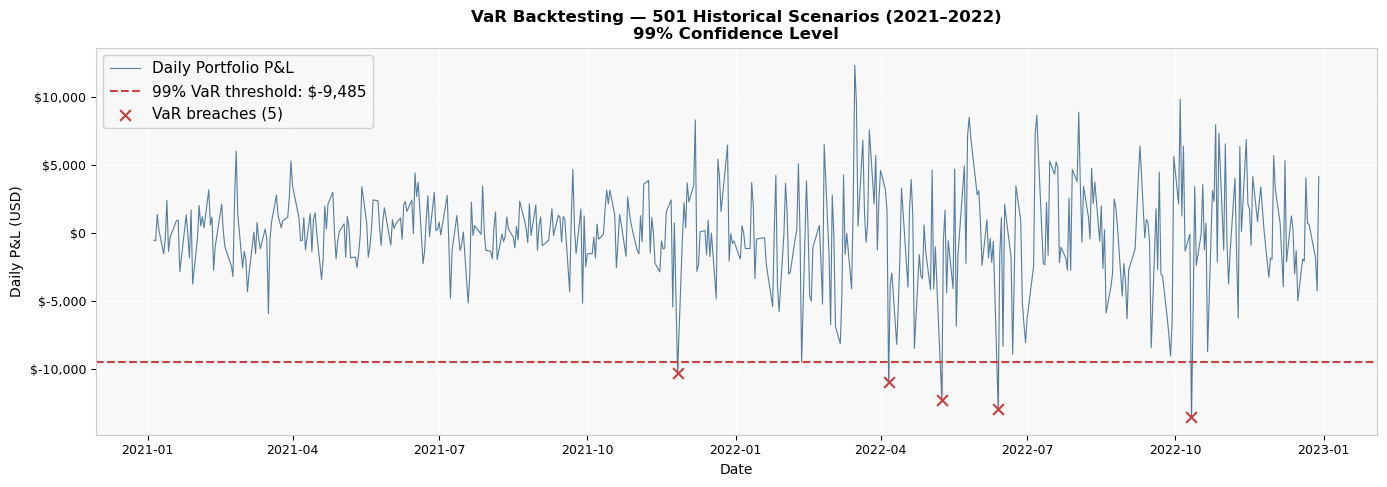

In [100]:
# VaR Backtesting — compare rolling VaR threshold against realized P&L
var_threshold = var99_portfolio  # our computed 1-day 99% VaR (negative number)

# Identify breach days
breaches = pnl_portfolio < var_threshold
n_breaches = breaches.sum()
breach_dates = dates[breaches].values
breach_pnl   = pnl_portfolio[breaches]

print(f"VaR Threshold (99%, 1-day): ${var_threshold:,.0f}")
print(f"Total scenarios: 501")
print(f"Number of VaR breaches: {n_breaches}")
print(f"Breach rate: {n_breaches/501*100:.2f}%")
print(f"Expected at 99% confidence: ~5 breaches")
print()
if n_breaches <= 4:
    zone = "GREEN — model is conservative"
elif n_breaches <= 9:
    zone = "GREEN — model is performing within expectations"
elif n_breaches <= 12:
    zone = "YELLOW — elevated breaches, model review recommended"
else:
    zone = "RED — excessive breaches, capital add-on required"
print(f"Basel III Traffic Light: {zone}")

# Backtesting chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, pnl_portfolio, color=PALETTE[0], linewidth=0.8,
        alpha=0.8, label='Daily Portfolio P&L')
ax.axhline(var_threshold, color=PALETTE[3], linewidth=1.5,
           linestyle='--', label=f'99% VaR threshold: ${var_threshold:,.0f}')
ax.scatter(dates[breaches], breach_pnl, color=PALETTE[3],
           zorder=5, s=60, label=f'VaR breaches ({n_breaches})', marker='x')
ax.fill_between(dates, pnl_portfolio, var_threshold,
                where=(pnl_portfolio < var_threshold),
                color=PALETTE[3], alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily P&L (USD)')
ax.set_title('VaR Backtesting — 501 Historical Scenarios (2021–2022)\n99% Confidence Level')
ax.legend(framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('output/var_backtesting.png', bbox_inches='tight', dpi=150)
plt.show()



<a id='correlation'></a>

## Risk Factor Correlation Analysis


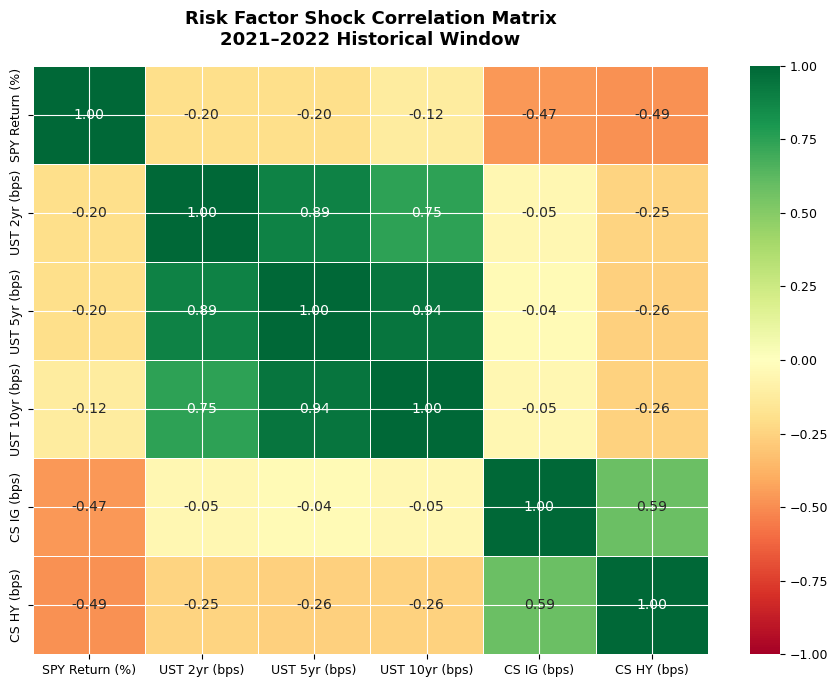

In [101]:
# Build risk factor shock dataframe
rf_df = pd.DataFrame({
    'SPY Return (%)':     daily_shock_SPY * 100,
    'UST 2yr (bps)':      daily_shock_UST_HY_2,
    'UST 5yr (bps)':      daily_shock_UST_5,
    'UST 10yr (bps)':     daily_shock_UST_IG_10,
    'CS IG (bps)':        daily_shock_CS_IG,
    'CS HY (bps)':        daily_shock_CS_HY,
})

corr = rf_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 10})
ax.set_title('Risk Factor Shock Correlation Matrix\n2021–2022 Historical Window',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()



The correlation matrix reveals several important relationships. UST yields across tenors (2yr, 5yr, 10yr) show strong positive correlation, reflecting parallel shifts during the 2022 Fed hiking cycle. SPY returns show a moderate negative correlation with yield changes — consistent with the equity-rates relationship that typically holds in risk-off environments. Notably, IG and HY credit spreads are positively correlated with each other but show weak correlation with rates, suggesting credit and rate risk are relatively independent in this window. This partial independence means the portfolio's CS01 exposure is largely unhedged by the short UST position.


<a id='frtb'></a>

## FRTB Liquidity Horizon Scaling


Under the **Fundamental Review of the Trading Book (FRTB)**, different risk factor classes are assigned minimum liquidity horizons reflecting how long it takes to hedge or exit a position in stress conditions. The 1-day VaR is scaled to these horizons using the square root of time rule:

$$VaR(T) = VaR(1\text{-day}) \times \sqrt{T}$$

| Risk Factor Class | FRTB Liquidity Horizon | Scale Factor |
|---|---|---|
| Equity (large cap) | 10 days | √10 ≈ 3.16 |
| IG Credit Spread | 40 days | √40 ≈ 6.32 |
| HY Credit Spread | 60 days | √60 ≈ 7.75 |
| Interest Rates | 20 days | √20 ≈ 4.47 |

Note: This scaling is illustrative. FRTB's Internal Models Approach uses ES (not VaR) and applies liquidity horizons at the risk factor level, not portfolio level.


In [102]:
# Decompose 1-day VaR into risk factor contributions
var_SPY = var99_SPY
var_IG  = var99_IG
var_HY  = var99_HY
var_UST = var99_UST

# FRTB liquidity horizons
lh_equity = 10
lh_ig_cs  = 40
lh_hy_cs  = 60
lh_rates  = 20

# Scale each component by its liquidity horizon
scaled_SPY = var_SPY * np.sqrt(lh_equity)
scaled_IG  = var_IG  * np.sqrt(lh_ig_cs)
scaled_HY  = var_HY  * np.sqrt(lh_hy_cs)
scaled_UST = var_UST * np.sqrt(lh_rates)

lh_df = pd.DataFrame({
    'Instrument':          ['SPY', 'IG Bond', 'HY Bond', 'UST (Short)'],
    'Risk Class':          ['Equity', 'IG Credit', 'HY Credit', 'Rates'],
    'Liquidity Horizon':   [lh_equity, lh_ig_cs, lh_hy_cs, lh_rates],
    '1-day VaR':           [round(var_SPY, 0), round(var_IG, 0),
                            round(var_HY, 0), round(var_UST, 0)],
    'Scaled VaR':          [round(scaled_SPY, 0), round(scaled_IG, 0),
                            round(scaled_HY, 0), round(scaled_UST, 0)],
})
display(lh_df)



,Instrument,Risk Class,Liquidity Horizon,1-day VaR,Scaled VaR
0,SPY,Equity,10,-387.0,-1223.0
1,IG Bond,IG Credit,40,-13084.0,-82753.0
2,HY Bond,HY Credit,60,-5602.0,-43395.0
3,UST (Short),Rates,20,-16920.0,-75669.0
